<a href="https://colab.research.google.com/github/dragoa/MachineLearning/blob/main/DeepLearning%20AI/%5BSPZ%5D%20PyTorch%20for%20Deep%20Learning/Module%205/Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning: Learning Rate and Metrics

Welcome to this first exploration of hyperparameter tuning using the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset! This dataset consists on 60,000 32x32 color images in 10 classes (6,000 images per class).

In this notebook, you'll focus specifically on the learning rate, an essential hyperparameter that dictates the pace at which a model learns during training. You'll work with a simple convolutional neural network (CNN) and observe how changes in hyperparameters affect the model's outcomes.

This lab will cover the following:

* Examining the effects of different **learning rates** on model performance.

* Introducing and using additional metrics like **precision, recall, and F1 score** for a more complete evaluation.

* Exploring the effect of **batch size** on different metrics using an imbalanced dataset in an optional section.

In [1]:
!pip install -qU torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchmetrics

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
class SimpleCNN(nn.Module):

  def __init__(self):

    # Initialize the parent class
    super(SimpleCNN, self).__init__()
    # First convolutional layer (3 input channels, 16 output channels, 3x3 kernel)
    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1 = nn.Linear(32 * 8 * 8, 64)
    # Dropout layer for regularization
    self.dropout = nn.Dropout(p=0.4)
    # Second fully connected layer as the output
    self.fc2 = nn.Linear(64, 10)

  def forward(self, x):

    # Apply first convolution, ReLU activation, and max pooling
    x = self.max_pool(F.relu(self.conv1(x)))
    # Apply second convolution, ReLU activation, and max pooling
    x = self.max_pool(F.relu(self.conv2(x)))
    # Flatten
    x = torch.flatten(x, start_dim=1)
    x = F.relu(self.fc1(x))
    # Apply dropout for regularization
    x = self.dropout(x)
    x = self.fc2(x)

    return x


In [5]:
def evaluate_accuracy(model, val_loader, device):

  model.eval()
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      # move values to device
      inputs, labels = inputs.to(device), labels.to(device)

      # predict
      outputs = model(inputs)

      # get the predicted class by finding the index of the maximum logit
      _, predicted = outputs.max(1)

      # update the total correct number of samples
      total_correct += (predicted == labels).sum().item()

      total_samples += labels.size(0)

  accuracy = total_correct / total_samples

  return accuracy

In [6]:
from types import DynamicClassAttribute
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import zipfile


def get_dataloaders(batch_size=64, subset_size=10_000, imbalanced=False):
  """
  Function to retrieve dataloaders for train and test from a subset of CIFAR10
  """

  transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
  ])

  # if imbalanced = True, load a custom imbalanced dataset
  if imbalanced:
    with zipfile.ZipFile("cifar10_3class_imbalanced.zip", "r") as zip_ref:
        zip_ref.extractall("./cifar10_3class_imbalanced")

    full_trainset = ImageFolder(root="./cifar10_3class_imbalanced", transform=transform)
    # Use the full size of the imbalanced dataset
    subset_size = None

  else:
    full_trainset = datasets.CIFAR10(root="./cifar10", train=True, download=True, transform=transform)

  if subset_size is None:
    subset_size = len(full_trainset)

  train_size = int(0.8*subset_size)
  val_size = subset_size - train_size

  # create a random subset from the dataset
  subset, _ = torch.utils.data.random_split(full_trainset, [subset_size, len(full_trainset) - subset_size])
  # split into train and test
  train_data, val_data = torch.utils.data.random_split(subset, [train_size, val_size])

  # create dataloader
  train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

  return train_loader, val_loader


In [7]:
def set_seed(seed=42):
  """
  Function to set seed for reproducibility
  """
  # set the seed for pyTorch on CPU
  torch.manual_seed(seed)
  # set the seed for all available GPUs
  torch.cuda.manual_seed_all(seed)
  # ensure that cuDNN's convolutional algorithms are deterministic
  torch.backends.cudnn.deterministic = True
  # disable the cuDNN benchmark for reproducibility
  torch.backends.cudnn.benchmark = False


In [8]:
def train_model(model, optimizer, loss_fcn, train_dataloader, device, n_epochs):

  train_losses = []

  for epoch in range(n_epochs):

    # get the average loss for the epoch
    train_loss, _ = train_epoch(model, optimizer, loss_fcn, train_dataloader, device)
    train_losses.append(train_loss)

    if epoch == 0 or (epoch+1)%5 == 0:
      print(f"Epoch {epoch + 1}: Train loss = {train_loss:.4f}")


def train_epoch(model, optimizer, loss_fcn, train_dataloader, device):

  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_idx, (inputs, labels) in enumerate(train_dataloader):
    inputs, labels = inputs.to(device), labels.to(device)
    # clear the gradients
    optimizer.zero_grad()
    # get the outputs
    outputs = model(inputs)
    # compute the loss
    loss = loss_fcn(outputs, labels)
    # perform backward process
    loss.backward()
    # update the gradients with a step
    optimizer.step()

    # accumulate loss for the epoch for the batch
    running_loss += loss.item() * inputs.size(0)

    # get the predicted class
    _, predicted = outputs.max(1)

    # get the total number of samples
    total += labels.size(0)

    # number of correctly classified samples
    correct += predicted.eq(labels).sum().item()

  # calculate the average loss for the epoch
  epoch_loss = running_loss / total
  # calculate the average accuracy for the epoch
  epoch_acc = correct / total

  return epoch_loss, epoch_acc


In the code below, the `train_and_evaluate` function:

- defines the model  
- sets up the optimizer with a specified learning rate and defines the loss function  
- prepares the train and validation dataloaders  
- trains the model for a specified number of epochs  
- evaluates the model's performance on the validation set

In [9]:
def train_and_evaluate(learning_rate, device, n_epochs=25, batch_size=128):

  # set seed for reproducibility
  set_seed(42)

  # initialize simple CNN model
  model = SimpleCNN().to(device)

  # define the loss function
  loss = nn.CrossEntropyLoss()

  # define the optimizer
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  train_loader, val_loader = get_dataloaders(batch_size=batch_size)

  # call the main training loop to train the model
  train_model(model, optimizer, loss, train_loader, device, n_epochs)

  # evaluate the trained model's accuracy on the validation set
  accuracy = evaluate_accuracy(model, val_loader, device)

  print(
      f"Learning Rate: {learning_rate}, Accuracy: {accuracy:.4f}"
  )

  return accuracy, model


In [10]:
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1] # low to high
accuracies = []
best_model = None
best_acc = 0

for lr in learning_rates:
    acc, model = train_and_evaluate(learning_rate=lr, device=device)
    accuracies.append(acc)

    if acc > best_acc:
      best_acc = acc
      best_model = model

100%|██████████| 170M/170M [01:01<00:00, 2.79MB/s]


Epoch 1: Train loss = 2.3017
Epoch 5: Train loss = 2.2588
Epoch 10: Train loss = 2.1827
Epoch 15: Train loss = 2.1124
Epoch 20: Train loss = 2.0537
Epoch 25: Train loss = 2.0044
Learning Rate: 1e-05, Accuracy: 0.3205
Epoch 1: Train loss = 2.2655
Epoch 5: Train loss = 1.8969
Epoch 10: Train loss = 1.7019
Epoch 15: Train loss = 1.5969
Epoch 20: Train loss = 1.5196
Epoch 25: Train loss = 1.4583
Learning Rate: 0.0001, Accuracy: 0.4905
Epoch 1: Train loss = 2.1046
Epoch 5: Train loss = 1.4902
Epoch 10: Train loss = 1.2833
Epoch 15: Train loss = 1.1305
Epoch 20: Train loss = 0.9694
Epoch 25: Train loss = 0.8585
Learning Rate: 0.001, Accuracy: 0.5930
Epoch 1: Train loss = 2.1605
Epoch 5: Train loss = 1.6912
Epoch 10: Train loss = 1.5567
Epoch 15: Train loss = 1.4811
Epoch 20: Train loss = 1.4062
Epoch 25: Train loss = 1.3708
Learning Rate: 0.01, Accuracy: 0.4345
Epoch 1: Train loss = 11.9108
Epoch 5: Train loss = 2.3073
Epoch 10: Train loss = 2.3103
Epoch 15: Train loss = 2.3094
Epoch 20: Tra

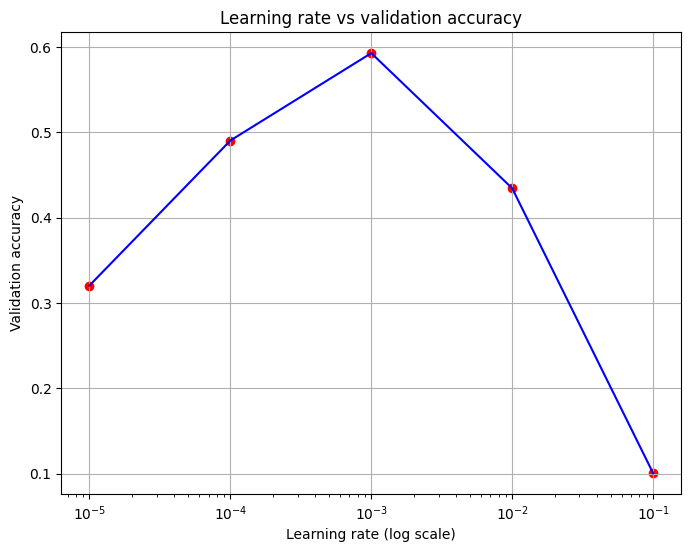

In [11]:
import matplotlib.pyplot as plt

def plot_results(learning_rates, accuracies):

  plt.figure(figsize=(8,6))
  plt.plot(learning_rates, accuracies, linestyle='-', color='blue')
  plt.scatter(learning_rates, accuracies, color='red')

  plt.xscale("log")
  plt.xlabel("Learning rate (log scale)")
  plt.ylabel("Validation accuracy")
  plt.title("Learning rate vs validation accuracy")
  plt.grid(True)
  plt.show()


plot_results(learning_rates, accuracies)

The plot shows that the learning rate of 0.001 provides the highest validation accuracy, indicating it is the **optimal choice** between the tested values.

Smaller learning rates leads to slower learning and lower accuracy, suggesting that the optimizer will take a long time to converge.
Larger learning rates results in unstable training and lower accuracy.

## Other relevant metrics: Recall, Precision, and F1 Score

Deep learning models are typically trained by optimizing a *loss function*, such as **cross-entropy loss**.
This loss quantifies the difference between the predicted probabilities and the true labels, guiding the model to adjust its parameters.
It provides a scalar loss that can be minimized using gradient-based optimization algorithms.

However, the loss function optimized during training does not always align with the **evaluation metrics** you care about in practice. Metrics like **accuracy**, **precision**, **recall**, and **F1 score** offer a more nuanced understanding of model performance.

-  **Accuracy**: The ratio of correct predictions to the total number of predictions.
But it can be misleading in **imbalanced datasets**, where the model may achieve high accuracy simply by predicting the majority class.

- **Precision and Recall**:
These metrics evaluate performance on a **per-class** basis, offering better insight into class-specific behaviors.
For each class $k$:
  $$
  \text{Precision}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k}
  $$
  $$
  \text{Recall}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k}
  $$

  Where:
  - **TPₖ** (True Positives): Correct predictions for class $k$.
  - **FPₖ** (False Positives): Instances incorrectly predicted as class $k$.
  - **FNₖ** (False Negatives): Instances truly belonging to class $k$ but predicted as another class.
  >
  
  To evaluate overall performance in a multiclass setting, these metrics can be aggregated:

  - **Macro-average**:
    Averages metrics across classes, treating all classes equally. *Useful when class balance is important.*
      - This is often used for **Precision, Recall, and F1** to prevent the majority class from dominating the score.
  >
  - **Micro-average**:
    Computes metrics globally by aggregating all TP, FP, and FN. *Useful when class sizes vary significantly.*
    - *Standard Accuracy* is calculated using this method (Total Correct / Total Samples).
  >  
  - **Weighted-average**:
    Averages metrics across classes, weighted by the number of true instances per class. *Balances influence of both major and minor classes.*
    - Use this when you want a metric that reflects the **true data distribution**, ensuring that performance on common classes contributes proportionately more to the final score than rare classes.
  >

- **F1 Score**:
  It combines precision and recall into a single number, useful when both false positives and false negatives are important:
  $$
  \text{F1}_k = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}
  $$
  Like precision and recall, it can be aggregated (macro, micro, weighted) depending on the evaluation goal.

All these metrics range from 0 to 1, where higher values indicate better performance. The goal is to maximize each metric.

Some use cases for these metrics include:

- **Precision** is essential when **false positives** are costly (e.g., spam detection, medical diagnosis).
- **Recall** is vital when **false negatives** are costly (e.g., disease screening, fraud detection).
- **F1 score** is ideal when both false positives and false negatives matter, as it provides a trade-off between the two.

In [12]:
def evaluate_metrics(model, val_loader, device, num_classes=10):

  model.eval()

  # initialize accuracy metric -> by default average is micro (standard accuracy)
  accuracy_metric = torchmetrics.Accuracy(
      task = "multiclass",
      num_classes = num_classes,
      average = "micro"
  ).to(device)

  # initialize precision metric
  # set average as "macro" to calculate the metric for each class independently and then average them
  precision_metric = torchmetrics.Precision(
      task = "multiclass",
      num_classes = num_classes,
      average="macro").to(device)

  recall_metric = torchmetrics.Recall(
      task = "multiclass",
      num_classes = num_classes,
      average="macro").to(device)

  f1_metric = torchmetrics.F1Score(
      task = "multiclass",
      num_classes = num_classes,
      average="macro").to(device)

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      # get output
      outputs = model(inputs)
      # get the predicted class
      _, predicted = torch.max(outputs, 1)

      # update metrics
      accuracy_metric.update(predicted, labels)
      precision_metric.update(predicted, labels)
      recall_metric.update(predicted, labels)
      f1_metric.update(predicted, labels)

  accuracy = accuracy_metric.compute().item()
  precision = precision_metric.compute().item()
  recall = recall_metric.compute().item()
  f1 = f1_metric.compute().item()

  return accuracy, precision, recall, f1


In [13]:
model = SimpleCNN().to(device)

_, val_loader = get_dataloaders(batch_size=128)

accuracy, precision, recall, f1 = evaluate_metrics(model=best_model, val_loader=val_loader, device=device)

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Accuracy: 0.6160, Precision: 0.6147, Recall: 0.6156, F1 Score: 0.6132


### How other metrics change with learning rate

*How do these metrics change with different learning rates?*  
To explore this, you will train the model with the same five learning rates and evaluate it using accuracy, precision, recall, and F1 score.

A new `train_and_evaluate_metrics` function is defined to handle the training and evaluation process.

In [14]:
def train_and_evaluate_metrics(learning_rate, device, n_epochs=25, batch_size=128, imbalanced=False):

  set_seed(42)

  # define our model
  model = SimpleCNN().to(device)

  # define loss function
  loss_function = nn.CrossEntropyLoss()

  # define optimizer
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  # get train and val dataloaders
  train_loader, val_loader = get_dataloaders(batch_size=batch_size, imbalanced=imbalanced)

  # call the main training loop to train the model
  train_model(model, optimizer, loss_function, train_loader, device, n_epochs)

  # compute metrics
  accuracy, precision, recall, f1 = evaluate_metrics(model, val_loader, device)

  print(
      f"Learning Rate: {learning_rate}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
  )


  return accuracy, precision, recall, f1


In [15]:
dict_metrics = []

for lr in learning_rates:

    # Train and evaluate the model, collecting metrics, for a given learning rate
    n_epochs = 25
    batch_size = 128
    acc, prec, rec, f1 = train_and_evaluate_metrics(learning_rate=lr, device=device, n_epochs=n_epochs, batch_size=batch_size, imbalanced=False)

    metrics_lr = {
        "learning_rate": lr,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
    }

    dict_metrics.append(metrics_lr)

# Convert the list of dictionaries to a DataFrame for easier plotting
df_metrics = pd.DataFrame(dict_metrics)

Epoch 1: Train loss = 2.3017
Epoch 5: Train loss = 2.2588
Epoch 10: Train loss = 2.1827
Epoch 15: Train loss = 2.1124
Epoch 20: Train loss = 2.0537
Epoch 25: Train loss = 2.0044
Learning Rate: 1e-05, Accuracy: 0.3205, Precision: 0.3364, Recall: 0.3204, F1: 0.2841
Epoch 1: Train loss = 2.2655
Epoch 5: Train loss = 1.8969
Epoch 10: Train loss = 1.7019
Epoch 15: Train loss = 1.5969
Epoch 20: Train loss = 1.5196
Epoch 25: Train loss = 1.4583
Learning Rate: 0.0001, Accuracy: 0.4905, Precision: 0.4839, Recall: 0.4881, F1: 0.4828
Epoch 1: Train loss = 2.1046
Epoch 5: Train loss = 1.4902
Epoch 10: Train loss = 1.2833
Epoch 15: Train loss = 1.1305
Epoch 20: Train loss = 0.9694
Epoch 25: Train loss = 0.8585
Learning Rate: 0.001, Accuracy: 0.5930, Precision: 0.5873, Recall: 0.5905, F1: 0.5865
Epoch 1: Train loss = 2.1605
Epoch 5: Train loss = 1.6912
Epoch 10: Train loss = 1.5567
Epoch 15: Train loss = 1.4811
Epoch 20: Train loss = 1.4062
Epoch 25: Train loss = 1.3708
Learning Rate: 0.01, Accuracy

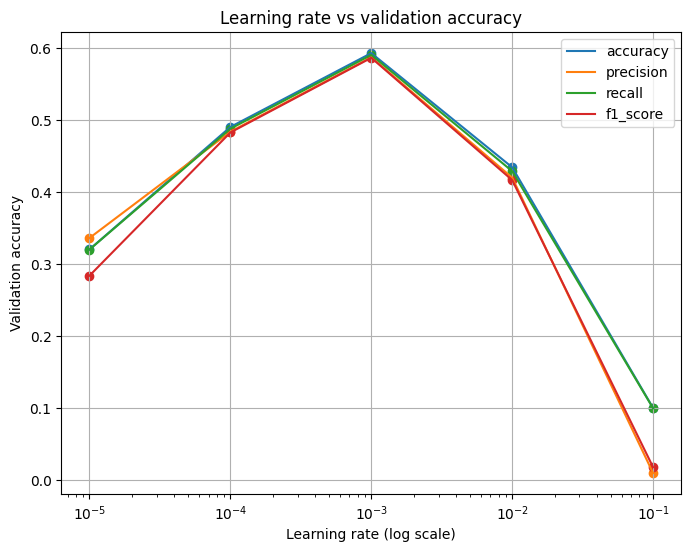

In [16]:
def plot_results_metrics(df_metrics):

  plt.figure(figsize=(8,6))

  for metric in ["accuracy", "precision", "recall", "f1_score"]:

    plt.plot(df_metrics["learning_rate"], df_metrics[metric], linestyle='-', label=metric)
    plt.scatter(df_metrics["learning_rate"], df_metrics[metric])

  plt.xscale("log")
  plt.xlabel("Learning rate (log scale)")
  plt.ylabel("Validation accuracy")
  plt.title("Learning rate vs validation accuracy")
  plt.grid(True)
  plt.legend()
  plt.show()


plot_results_metrics(df_metrics)

In this case, since the dataset is **balanced**, you can observe that all metrics (accuracy, precision, recall, F1-score) behave similarly for most learning rates, and the value of $10^{-3}$ achieves the best performance across the board.

## Further Exploration: Batch Size Optimization on an Imbalanced Dataset

In this section, you'll revisit the previous experiments with the following setup:

- **Learning Rate:** will be set to $10^{−3}$.
- **Imbalanced Dataset:** You'll work with a customized subset of the CIFAR-10 dataset to better observe how metrics are affected by class imbalance.

The new variable you'll explore is **Batch Size**. You will vary its values (32, 64, and 128) to see how these influence different performance metrics.

**Class Imbalanced CIFAR-10 Dataset**
For this experiment, a subset of the CIFAR-10 dataset has been crafted to simulate class imbalance, focusing on three classes: `Cat`, `Dog`, and `Frog`. To mimic a scenario where some classes are more prevalent, the dataset includes all available `Cat` instances, while reducing the number of samples for the other two classes. Specifically, 50% of the original `Dog` images and only 20% of the `Frog` images are retained. As a result, the dataset comprises:

- 6,000 `Cat` images
- 3,000 `Dog` images
- 1,200 `Frog` images

This setup creates a pronounced imbalance, spotlighting the `Cat` class and reflecting real-world situations where certain classes are underrepresented.

In [18]:
dict_metrics = []

# Loop through different batch sizes and collect metrics
batch_sizes = [32, 64, 128]

# Set a fixed learning rate
lr = 0.001  # Medium learning rate

# Set imbalance to True to use imbalanced dataset
imbalanced = True

n_epochs = 25

for bs in batch_sizes:
    acc, prec, rec, f1 = train_and_evaluate_metrics(batch_size=bs, n_epochs=n_epochs, learning_rate=lr, device=device, imbalanced=imbalanced)

    metrics_bs = {
        "batch_size": bs,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
    }
    dict_metrics.append(metrics_bs)

df_metrics = pd.DataFrame(dict_metrics)

Epoch 1: Train loss = 0.9354
Epoch 5: Train loss = 0.6701
Epoch 10: Train loss = 0.5458
Epoch 15: Train loss = 0.4364
Epoch 20: Train loss = 0.3223
Epoch 25: Train loss = 0.2276
Learning Rate: 0.001, Accuracy: 0.7088, Precision: 0.6838, Recall: 0.6789, F1: 0.6811
Epoch 1: Train loss = 0.9846
Epoch 5: Train loss = 0.7135
Epoch 10: Train loss = 0.6114
Epoch 15: Train loss = 0.5182
Epoch 20: Train loss = 0.4332
Epoch 25: Train loss = 0.3389
Learning Rate: 0.001, Accuracy: 0.7165, Precision: 0.7070, Recall: 0.6912, F1: 0.6987
Epoch 1: Train loss = 1.0724
Epoch 5: Train loss = 0.7623
Epoch 10: Train loss = 0.6545
Epoch 15: Train loss = 0.5917
Epoch 20: Train loss = 0.5397
Epoch 25: Train loss = 0.4781
Learning Rate: 0.001, Accuracy: 0.7112, Precision: 0.6891, Recall: 0.6728, F1: 0.6775


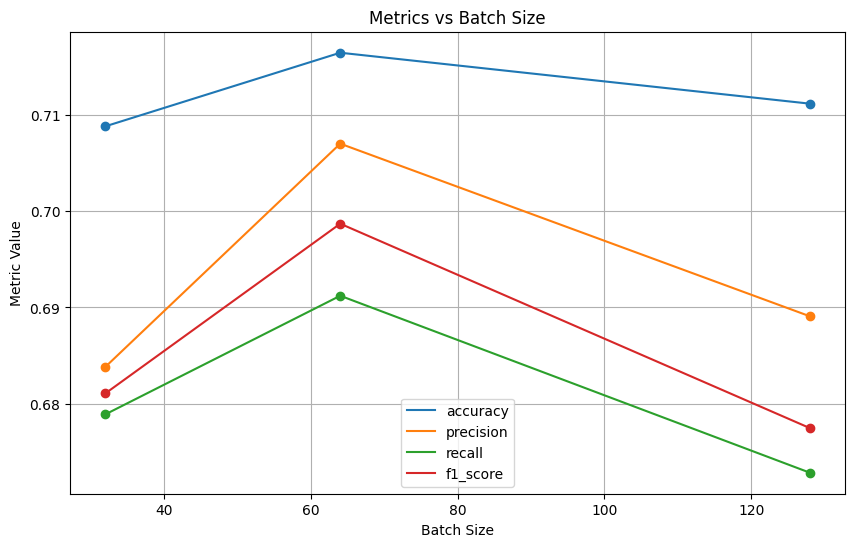

In [19]:
def plot_metrics_vs_batch_size(df_metrics):

    plt.figure(figsize=(10, 6))

    # Iterate through the metrics and plot each one against the batch size
    for metric in ["accuracy", "precision", "recall", "f1_score"]:
        plt.plot(df_metrics["batch_size"], df_metrics[metric], linestyle='-', label=metric)
        plt.scatter(
            df_metrics["batch_size"],
            df_metrics[metric],
            marker="o",
        )

    plt.xlabel("Batch Size")
    plt.ylabel("Metric Value")
    plt.title("Metrics vs Batch Size")
    plt.legend()
    plt.grid(True)


plot_metrics_vs_batch_size(df_metrics)

Observe that the optimal batch size depends significantly on the metric being prioritized. **It's common to find that one batch size may optimize a particular metric, while a different batch size yields better results for another**. In conclusion, *a parameter that is optimal for one metric might not be optimal for another*.